# Benchmarking tools — distribution of orientation

Compares the **distribution of orientation** produced by seven tools on 4 images of
[../../orientationj-test-images](../../orientationj-test-images) — `synthetic_rings_dither_512`,
`synthetic_nematic_512`, `synthetic_noise_512`, `collagen` — all with the
**cubic-spline gradient** and a structure-tensor window **σ = 1** wherever the tool
exposes those choices. Two comparisons are drawn:

- **masked** — only the pixels inside the mask of
  [../../orientationj-test-images/masks](../../orientationj-test-images/masks); without Directionality,
  which has no mask support;
- **full** — every pixel of the image; without the direct gradient, whose
  unsmoothed histogram is dominated by the degenerate flat-background spikes.

| tool | orientation source |
|---|---|
| OrientationJ (Fiji) | [macro-orientationj.ijm](macro-orientationj.ijm) saves the orientation maps; binned here |
| OrientationJ Python port | [../../orientationj-python-port/orientationj.py](../../orientationj-python-port/orientationj.py), `analysis(σ = 1)` |
| OrientationPy | `computeGradient(mode='splines')` → `computeStructureTensor(σ = 1)` → `computeOrientation(mode='fiber')` |
| GST minimal | [gst_minimal.py](gst_minimal.py) — the whole operator in ~15 lines: Gaussian-derivative gradient and Gaussian window, analytic in Fourier |
| scikit-image | `feature.structure_tensor(σ = 1)` (its gradient is a finite difference), θ = ½ atan2(2A₍rc₎, A₍rr₎ − A₍cc₎) |
| direct gradient | per-pixel angle perpendicular to the spline gradient — no tensor smoothing (σ = 0) |
| Directionality (Fiji) | [script-directionality.groovy](script-directionality.groovy), Local-gradient method, own histogram |

All tools share the OrientationJ angle convention (checked on calibration
sinusoids): degrees in [−90, +90], counter-clockwise from the horizontal of the
displayed image. Histograms use the plugin's binning: 180 bins of 1°, normalized
to probability per bin.

Several tools coincide almost exactly (the Fiji plugin and the Python port are
identical, OrientationPy nearly so), so the overlays differentiate them by **line
style**: the Fiji plugin is a thick solid base line, the port rides on it dashed,
OrientationPy dotted; the y-limits hug the data instead of starting at zero, which
magnifies the structure of the nearly flat histograms. The RMSE table at the end
quantifies what remains invisible.

**Before running this notebook**, produce the Fiji results (kept in `results/fiji/`):

```
Fiji.app/Contents/MacOS/ImageJ-macosx --headless --console -macro  macro-orientationj.ijm
Fiji.app/Contents/MacOS/ImageJ-macosx --headless --console --run   script-directionality.groovy
```

(`macro-directionality.ijm` does the same as the groovy script from the Fiji GUI.)
Outputs: `results/<name>-distributions-masked.csv` and `-full.csv`,
`results/benchmark-statistics.csv`, and the two summary figures
`benchmark-distributions-masked.png` / `-full.png` written next to the README.

In [1]:
import os
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tifffile

sys.path.insert(0, os.path.join('..', '..', 'orientationj-python-port'))
import orientationj as oj
import orientationpy
from skimage.feature import structure_tensor

import gst_minimal

SIGMA = 1.0
IMAGES = ['synthetic_rings_dither_512', 'synthetic_nematic_512',
          'synthetic_noise_512', 'collagen']
INPUT = os.path.join('..', '..', 'orientationj-test-images')
MASKS = os.path.join(INPUT, 'masks')
FIJI = os.path.join('results', 'fiji')
OUTPUT = 'results'
os.makedirs(OUTPUT, exist_ok=True)

ANGLES = np.arange(180) - 89.5

# fixed tool order and colors (Okabe-Ito, color-blind safe)
COLORS = {'OrientationJ (Fiji)': '#0072B2',
          'OrientationJ Python port': '#E69F00',
          'OrientationPy': '#009E73',
          'GST minimal': '#000000',
          'scikit-image': '#CC79A7',
          'direct gradient': '#56B4E9',
          'Directionality (Fiji)': '#D55E00'}
MASKED_TOOLS = ['OrientationJ (Fiji)', 'OrientationJ Python port', 'OrientationPy',
                'GST minimal', 'scikit-image', 'direct gradient']
FULL_TOOLS = ['OrientationJ (Fiji)', 'OrientationJ Python port', 'OrientationPy',
              'GST minimal', 'scikit-image', 'Directionality (Fiji)']

# coinciding curves are told apart by line style: thick solid base for the Fiji
# plugin, the port dashed on top of it, OrientationPy dotted
STYLES = {'OrientationJ (Fiji)': dict(linestyle='-', linewidth=2.6),
          'OrientationJ Python port': dict(linestyle=(0, (5, 4)), linewidth=1.4),
          'OrientationPy': dict(linestyle=(0, (1, 1.8)), linewidth=1.8),
          'GST minimal': dict(linestyle='-', linewidth=1.0, alpha=0.85),
          'scikit-image': dict(linestyle='-', linewidth=1.2, alpha=0.85),
          'direct gradient': dict(linestyle='-', linewidth=1.2, alpha=0.85),
          'Directionality (Fiji)': dict(linestyle='-', linewidth=1.2, alpha=0.85)}

plt.rcParams.update({
    'figure.facecolor': 'white', 'font.size': 10, 'axes.titlesize': 10,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.edgecolor': '#cfcec6', 'grid.color': '#e8e8e4', 'grid.linewidth': 0.8,
    'text.color': '#3a3a37', 'axes.labelcolor': '#3a3a37',
    'xtick.color': '#6b6a63', 'ytick.color': '#6b6a63'})

images = {name: oj.load(os.path.join(INPUT, name + '.tif')) for name in IMAGES}
masks = {name: tifffile.imread(os.path.join(MASKS, name + '.tif')) > 0
         for name in IMAGES}
for name in IMAGES:
    print(f'{name:32s} {str(images[name].shape):14s} mask '
          f'{100 * masks[name].mean():5.1f} %')

synthetic_rings_dither_512       (512, 512)     mask  21.0 %
synthetic_nematic_512            (512, 512)     mask  73.5 %
synthetic_noise_512              (512, 512)     mask  82.7 %
collagen                         (512, 512)     mask  40.2 %


In [2]:
# orientation maps in degrees, one per pixel-based tool
thetas = {name: {} for name in IMAGES}
for name in IMAGES:
    image = images[name]

    # OrientationJ Python port (spline gradient, sigma = 1)
    f = oj.analysis(image, sigma=SIGMA)
    thetas[name]['OrientationJ Python port'] = np.degrees(f['orientation'])

    # direct gradient: same spline gradient, no tensor smoothing
    f0 = oj.analysis(image, sigma=0.0)
    thetas[name]['direct gradient'] = np.degrees(f0['orientation'])

    # OrientationPy (spline gradient, sigma = 1, fiber orientation in degrees)
    gradients = orientationpy.computeGradient(image, mode='splines')
    tensor = orientationpy.computeStructureTensor(gradients, sigma=SIGMA)
    thetas[name]['OrientationPy'] = \
        orientationpy.computeOrientation(tensor, mode='fiber')['theta']

    # GST minimal: the operator in ~15 lines (Gaussian-derivative gradient)
    thetas[name]['GST minimal'] = gst_minimal.orientation(image, sigma=SIGMA)

    # scikit-image (np.gradient derivatives, Gaussian window sigma = 1)
    Arr, Arc, Acc = structure_tensor(image, sigma=SIGMA, mode='mirror', order='rc')
    thetas[name]['scikit-image'] = np.degrees(0.5 * np.arctan2(2.0 * Arc, Arr - Acc))

    # OrientationJ (Fiji): orientation map saved by macro-orientationj.ijm
    path = os.path.join(FIJI, 'OJ-Orientation-' + name + '.tif')
    if os.path.exists(path):
        thetas[name]['OrientationJ (Fiji)'] = tifffile.imread(path).astype(np.float64)
    else:
        print('missing (run macro-orientationj.ijm):', path)
    print('computed', name)

computed synthetic_rings_dither_512


computed synthetic_nematic_512


computed synthetic_noise_512


computed collagen


In [3]:
def density(theta_degrees, mask):
    """OrientationJ binning of an orientation map: 180 bins of 1 degree,
    normalized to probability per bin."""
    bins = np.clip(np.floor(90.0 + theta_degrees).astype(int), 0, 179)
    counts = np.bincount(bins[mask], minlength=180).astype(float)
    return counts / counts.sum()


masked_densities = {name: {tool: density(theta, masks[name])
                           for tool, theta in thetas[name].items()
                           if tool in MASKED_TOOLS}
                    for name in IMAGES}
full_densities = {name: {tool: density(theta, np.ones(images[name].shape, bool))
                         for tool, theta in thetas[name].items()
                         if tool in FULL_TOOLS}
                  for name in IMAGES}

# Directionality (Fiji): own normalized histogram, whole image only;
# interpolated onto the common bin centers
for name in IMAGES:
    path = os.path.join(FIJI, 'Directionality-' + name + '.csv')
    if os.path.exists(path):
        table = pd.read_csv(path)
        frequency = np.interp(ANGLES, table['Direction'], table['Frequency'])
        full_densities[name]['Directionality (Fiji)'] = frequency / frequency.sum()
    else:
        print('missing (run script-directionality.groovy):', path)
print('densities ready')

densities ready


## The two comparisons

One panel per image, all tools overlaid. The two OrientationJ curves are identical
by construction — the dashed port alternates with the thick solid Fiji line
underneath; OrientationPy is dotted. The y-limits hug the data (they do not start
at zero) so the structure of the nearly flat histograms stays visible.

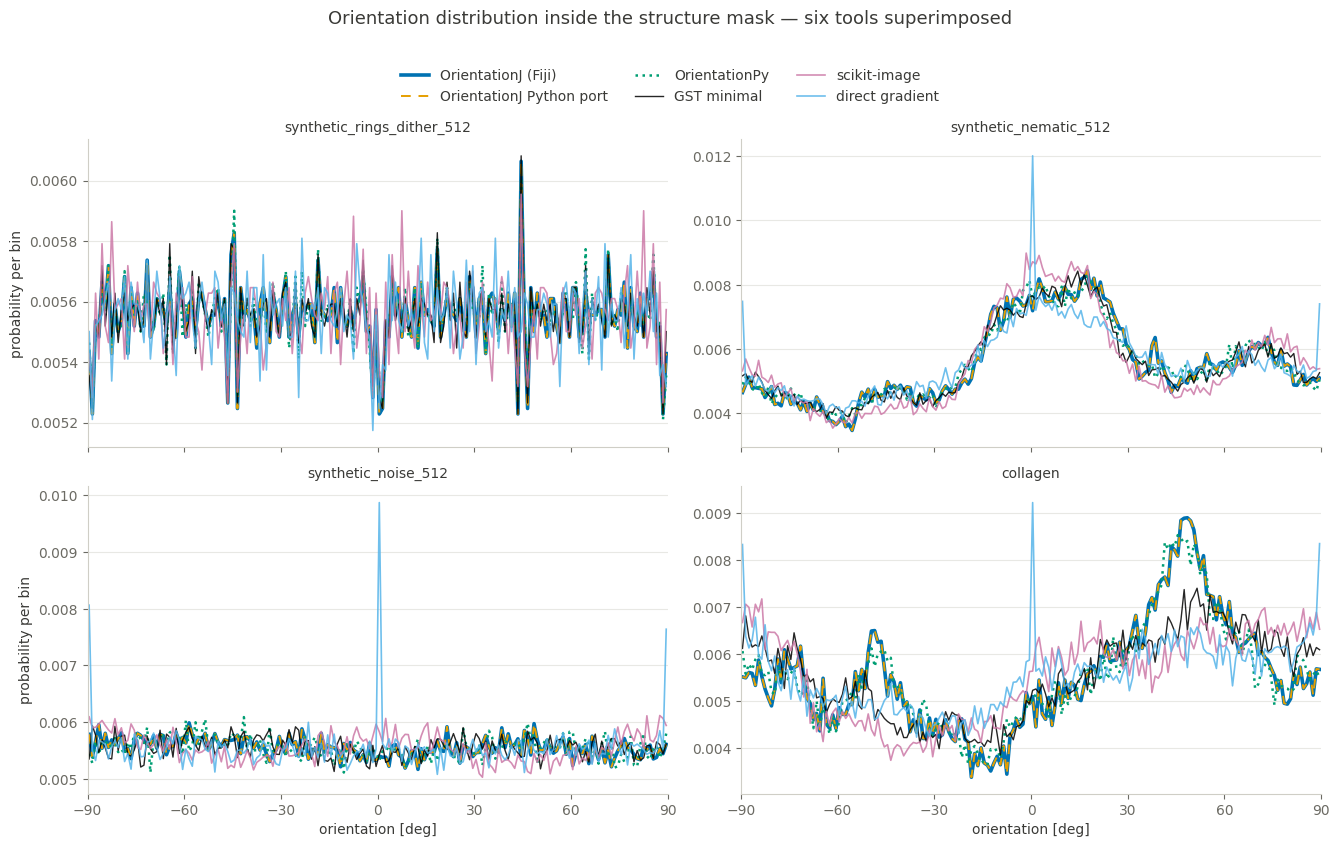

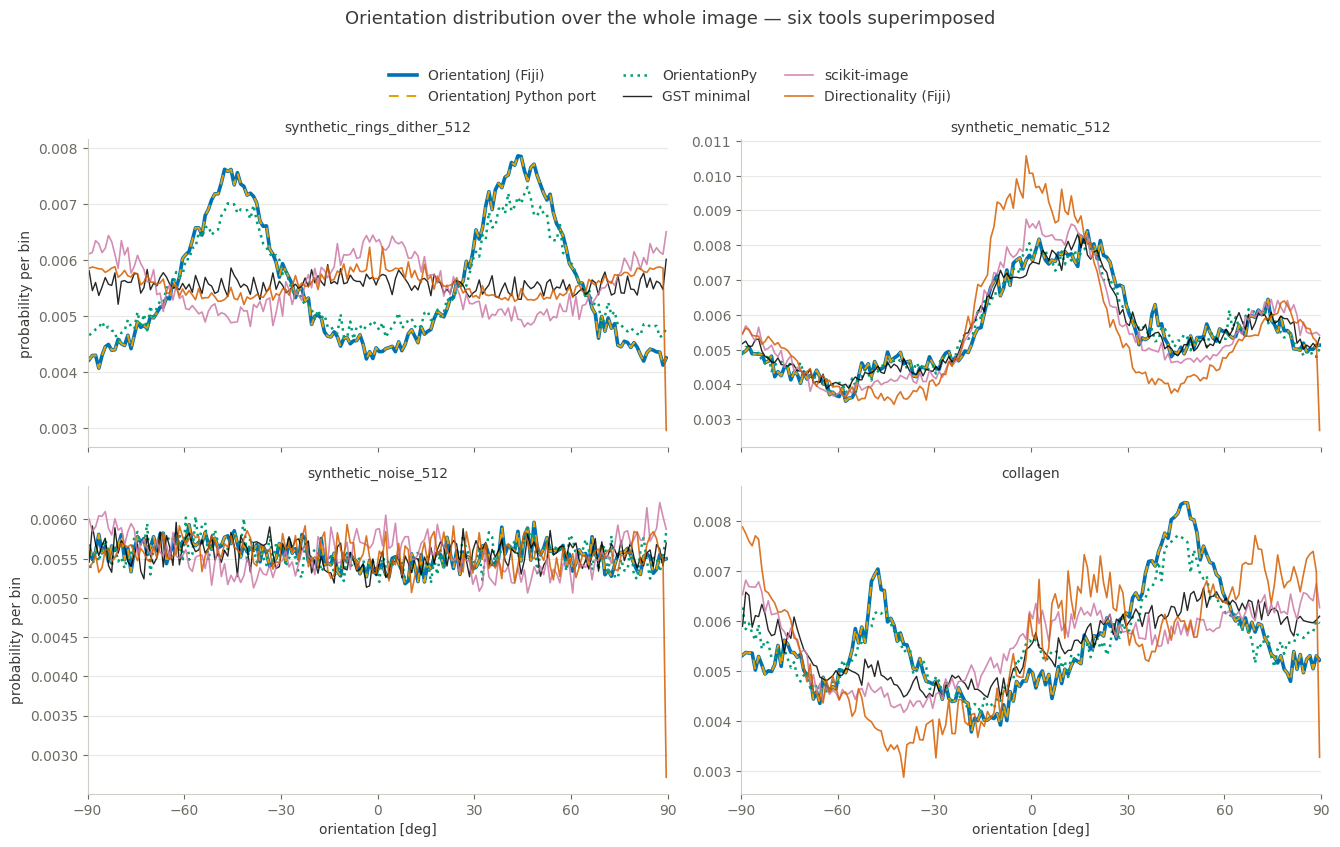

In [4]:
def plot_comparison(densities, tools, title, path):
    fig, axes = plt.subplots(2, 2, figsize=(13.5, 7.8), sharex=True)
    for ax, name in zip(axes.flat, IMAGES):
        available = [tool for tool in tools if tool in densities[name]]
        for tool in available:
            ax.plot(ANGLES, densities[name][tool], color=COLORS[tool],
                    label=tool, **STYLES[tool])
        lo = min(densities[name][tool].min() for tool in available)
        hi = max(densities[name][tool].max() for tool in available)
        pad = 0.06 * (hi - lo)
        ax.set_ylim(lo - pad, hi + pad)
        ax.set_xlim(-90, 90)
        ax.set_xticks(range(-90, 91, 30))
        ax.set_title(name, fontsize=10)
        ax.grid(True, axis='y')
        ax.set_axisbelow(True)
    for ax in axes[:, 0]:
        ax.set_ylabel('probability per bin')
    for ax in axes[1, :]:
        ax.set_xlabel('orientation [deg]')
    handles, labels = axes.flat[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', ncol=3, frameon=False,
               bbox_to_anchor=(0.5, 1.02))
    fig.suptitle(title, fontsize=13, y=1.08)
    fig.tight_layout()
    fig.savefig(path, dpi=150, bbox_inches='tight')
    plt.show()


# the two summary figures are written next to the README, which embeds them
plot_comparison(masked_densities, MASKED_TOOLS,
                'Orientation distribution inside the structure mask — six tools superimposed',
                'benchmark-distributions-masked.png')
plot_comparison(full_densities, FULL_TOOLS,
                'Orientation distribution over the whole image — six tools superimposed',
                'benchmark-distributions-full.png')

## Statistics and agreement

Per image, tool and version: dominant orientation (fullest bin), axial circular
mean, axial order parameter R, and the RMSE to the OrientationJ Python port of
the same version — the root-mean-square difference of the two normalized
histograms over the 180 bins, in units of 10⁻³ probability per bin
(0 = identical distributions).

In [5]:
def axial_stats(density_row):
    theta2 = np.radians(2.0 * ANGLES)
    c = (density_row * np.cos(theta2)).sum()
    s = (density_row * np.sin(theta2)).sum()
    return ANGLES[np.argmax(density_row)], \
        0.5 * np.degrees(np.arctan2(s, c)), np.hypot(c, s)


rows = []
for version, densities, tools in (('masked', masked_densities, MASKED_TOOLS),
                                  ('full', full_densities, FULL_TOOLS)):
    for name in IMAGES:
        reference = densities[name]['OrientationJ Python port']
        for tool in tools:
            if tool not in densities[name]:
                continue
            d = densities[name][tool]
            dominant, mean, order = axial_stats(d)
            rmse = np.sqrt(np.mean((d - reference) ** 2))
            rows.append({'image': name, 'version': version, 'tool': tool,
                         'dominant [deg]': dominant,
                         'axial mean [deg]': round(mean, 2),
                         'order parameter R': round(order, 4),
                         'RMSE to port [1e-3]': round(1e3 * rmse, 4)})
stats = pd.DataFrame(rows)
stats.to_csv(os.path.join(OUTPUT, 'benchmark-statistics.csv'), index=False)

for version, densities, tools in (('masked', masked_densities, MASKED_TOOLS),
                                  ('full', full_densities, FULL_TOOLS)):
    for name in IMAGES:
        table = pd.DataFrame({'Orientation': ANGLES})
        for tool in tools:
            if tool in densities[name]:
                table[tool] = densities[name][tool]
        table.to_csv(os.path.join(OUTPUT, name + '-distributions-' + version + '.csv'),
                     index=False)
print('written per-image CSVs and', os.path.join(OUTPUT, 'benchmark-statistics.csv'))
stats

written per-image CSVs and results/benchmark-statistics.csv


,image,version,tool,dominant [deg],axial mean [deg],order parameter R,RMSE to port [1e-3]
0,synthetic_rings_dither_512,masked,OrientationJ (Fiji),44.5,-4.26,0.0001,0.0000
1,synthetic_rings_dither_512,masked,OrientationJ Python port,44.5,-4.26,0.0001,0.0000
2,synthetic_rings_dither_512,masked,OrientationPy,44.5,2.95,0.0001,0.0534
3,synthetic_rings_dither_512,masked,GST minimal,44.5,1.57,0.0001,0.0439
4,synthetic_rings_dither_512,masked,scikit-image,44.5,-1.20,0.0001,0.1315
5,synthetic_rings_dither_512,masked,direct gradient,-23.5,0.55,0.0001,0.1215
6,synthetic_nematic_512,masked,OrientationJ (Fiji),17.5,18.65,0.1265,0.0000
7,synthetic_nematic_512,masked,OrientationJ Python port,17.5,18.65,0.1265,0.0000
8,synthetic_nematic_512,masked,OrientationPy,17.5,18.44,0.1223,0.3282
9,synthetic_nematic_512,masked,GST minimal,14.5,18.61,0.1168,0.3520
